In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd
from utils.helpers import to_pow_10


In [3]:
results_dir = Path("scratch") / "results"
figures_dir = Path("scratch") / "figures"
figures_dir.mkdir(exist_ok=True, parents=True)


def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# stats_df = combine_dfs("bsbm_stats*.csv", results_dir)
# timings_df = combine_dfs("bsbm_timings*.csv", results_dir)
modes = {
    "bsbm": "BSBM",
    "dbpedia": "DBpedia",
}
mode = "dbpedia"
timings_df = pd.read_csv(Path("scratch") / "results" / mode / f"{mode}_timings_all.csv")
stats_df = pd.read_csv(Path("scratch") / "results" / mode / f"{mode}_stats_all.csv")

In [4]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,421770566,8,-1,inf,0,Qlever,hard,embedded,-1.0
1,421770566,8,-1,9.637141,0,Qlever,hard,index,-1.0
2,421770566,8,-1,5.254781,1,Qlever,hard,index,-1.0
3,421770566,8,-1,5.386901,2,Qlever,hard,index,-1.0
4,421770566,8,-1,5.453136,3,Qlever,hard,index,-1.0
...,...,...,...,...,...,...,...,...,...
894,421770566,8,-1,3.920950,123,Fuseki,easy,embedded,1.0
895,421770566,8,-1,4.041937,124,Fuseki,easy,embedded,1.0
896,421770566,8,-1,3.928132,125,Fuseki,easy,embedded,1.0
897,421770566,8,-1,4.255762,126,Fuseki,easy,embedded,1.0


In [5]:
hard_timings = timings_df[timings_df["difficulty"] == "hard"]
hard_timings

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,421770566,8,-1,inf,0,Qlever,hard,embedded,-1.0
1,421770566,8,-1,9.637141,0,Qlever,hard,index,-1.0
2,421770566,8,-1,5.254781,1,Qlever,hard,index,-1.0
3,421770566,8,-1,5.386901,2,Qlever,hard,index,-1.0
4,421770566,8,-1,5.453136,3,Qlever,hard,index,-1.0
...,...,...,...,...,...,...,...,...,...
510,421770566,8,-1,5.272916,124,Qlever (no Tensor Vocabulary),hard,index,-1.0
511,421770566,8,-1,5.280232,125,Qlever (no Tensor Vocabulary),hard,index,-1.0
512,421770566,8,-1,5.285580,126,Qlever (no Tensor Vocabulary),hard,index,-1.0
513,421770566,8,-1,5.252510,127,Qlever (no Tensor Vocabulary),hard,index,-1.0


In [6]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['Qlever', 'Qlever (no Tensor Vocabulary)', 'Fuseki']
Length: 3, dtype: str

In [7]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [21]:
engines = list(timings_df["engine"].unique())
engines.sort()
baseline_engine = engines[0]


# calculate the median speedup vs the baseline engine for each difficulty + query type + engine + size
# the baseline engine
def calculate_speedup(
    df: pd.DataFrame, baseline_engine: str, baseline_type: str, relevant_measure: str
) -> pd.DataFrame:
    medians = (
        df.groupby(["difficulty", "query_type", "engine", "estimated_size", "size"])[
            relevant_measure
        ]
        .median()
        .reset_index()
    )
    baseline_medians = medians[
        (medians["engine"] == baseline_engine)
        & (medians["query_type"] == baseline_type)
    ]
    merged = medians.merge(
        baseline_medians,
        on=["difficulty", "estimated_size", "size"],
        suffixes=("", "_baseline"),
    )

    merged["speedup"] = (
        merged[f"{relevant_measure}_baseline"] / merged[relevant_measure]
    )
    merged = merged[merged["engine"] != baseline_engine]
    return merged[
        ["difficulty", "query_type", "engine", "estimated_size", "size", "speedup"]
    ]


calculate_speedup(timings_df, baseline_engine, "embedded", "elapsed_time")


,difficulty,query_type,engine,estimated_size,size,speedup
1,easy,embedded,Qlever,-1,421770566,1.489653
2,easy,embedded,Qlever (no Tensor Vocabulary),-1,421770566,1.563474
3,easy,index,Qlever,-1,421770566,1.340275
4,easy,index,Qlever (no Tensor Vocabulary),-1,421770566,1.339633
6,hard,embedded,Qlever,-1,421770566,NaN
7,hard,embedded,Qlever (no Tensor Vocabulary),-1,421770566,NaN
8,hard,index,Qlever,-1,421770566,inf
9,hard,index,Qlever (no Tensor Vocabulary),-1,421770566,inf


In [9]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [10]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'Qlever': 'C0', 'Qlever (no Tensor Vocabulary)': 'C1', 'Fuseki': 'C2'}

In [11]:
import matplotlib.pyplot as plt
import tikzplotlib
import seaborn as sns
import numpy as np

plt.rc("text", usetex=True)
plt.rc("text.latex", preamble="""\\usepackage{amsmath}""")
plt.style.use("fivethirtyeight")
# set background color to white of the figure and axes
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

palette = sns.color_palette('colorblind').as_hex()
def adjust_lightness(color, amount=1.1):
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], np.maximum(0, np.minimum(1, amount * c[1])), c[2])

plt.rcParams.update({'errorbar.capsize': 2})

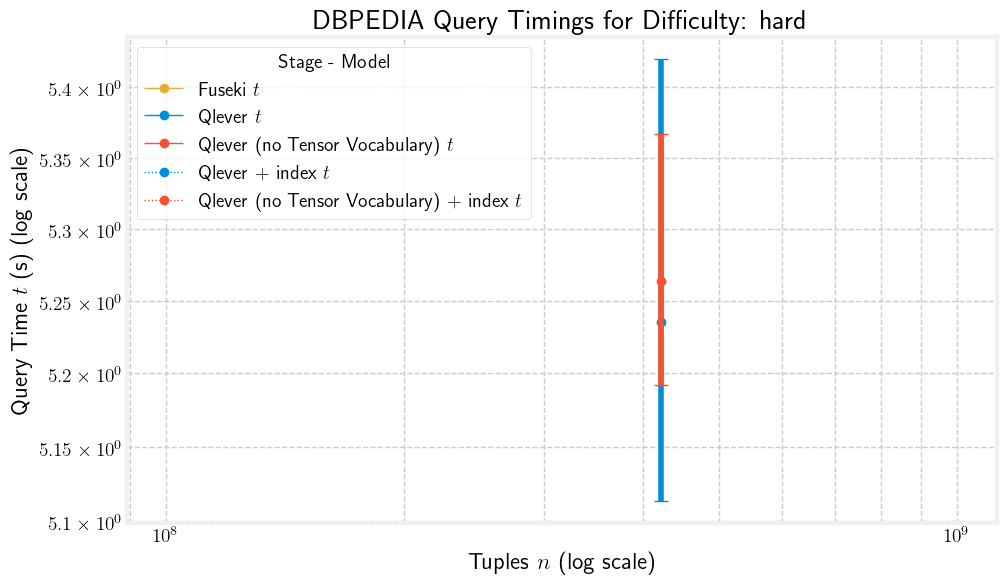

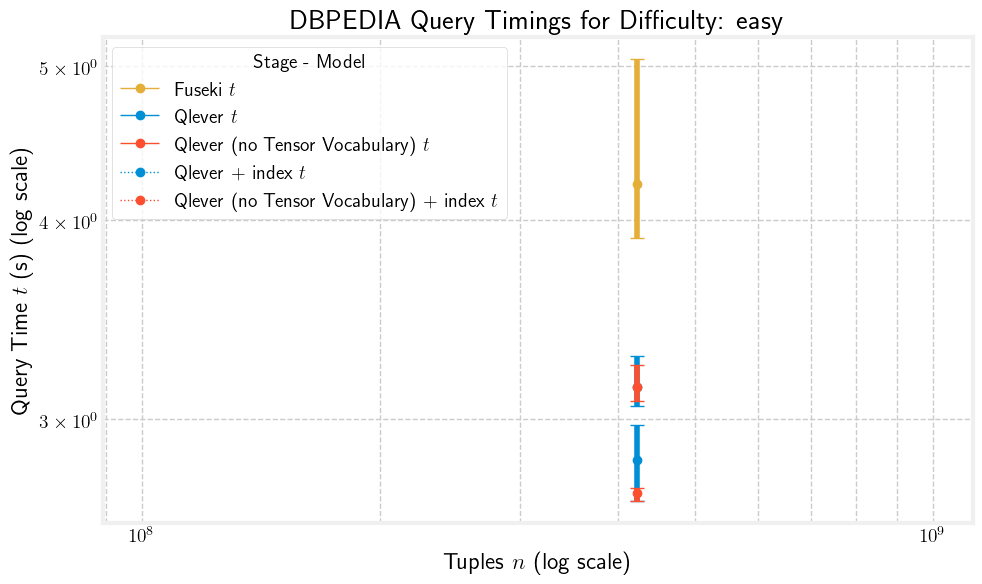

In [15]:
from numpy.polynomial import Polynomial


def extrapolate_missing_sizes(df, possible_sizes, relevant_measure):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]
    missing_sizes = [s for s in possible_sizes if s not in df_filtered["size"].unique()]
    if df_filtered.empty or len(missing_sizes) == 0:
        return None
    poly = Polynomial.fit(df_filtered["size"], df_filtered[relevant_measure], deg=1)
    if poly.coef.size == 0:
        return None
    extrapolated_measures = poly(missing_sizes)
    extrapolated_df = pd.DataFrame(
        {
            "size": missing_sizes,
            relevant_measure: extrapolated_measures,
        }
    )
    if extrapolated_df.empty:
        return None
    # add last known size and measure to the extrapolated df to make the plot look better
    last_known_size = df_filtered["size"].max()
    last_known_measure = df_filtered[df_filtered["size"] == last_known_size][
        relevant_measure
    ].values[0]
    extrapolated_df = pd.concat(
        [
            pd.DataFrame(
                {"size": [last_known_size], relevant_measure: [last_known_measure]}
            ),
            extrapolated_df,
        ],
        ignore_index=True,
    )
    return extrapolated_df


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(
    ax, df, engine, difficulty, relevant_measure="elapsed_time", extrapolate=True
):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    mean_timings = groupings.mean().reset_index()
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    possible_sizes = sorted(df["size"].unique())
    for query_type in QUERY_TYPE:
        for engine in mean_timings["engine"].unique():
            engine_mean = mean_timings[
                (mean_timings["query_type"] == query_type.value)
                & (mean_timings["difficulty"] == difficulty)
                & (mean_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            if engine_mean.empty or engine_quantiles.empty:
                continue

            extrapolated_df = None
            engine_median = engine_median[engine_median[relevant_measure].notna()]
            # extrapolate missing sizes by linear regression

            if extrapolate:
                extrapolated_df = extrapolate_missing_sizes(
                    engine_median, possible_sizes, relevant_measure
                )

            # index are dashed, embedded are solid
            linestyle = ":" if query_type == QUERY_TYPE.INDEX else "-"
            lbl = f"{engine}"
            if query_type.value != QUERY_TYPE.EMBEDDED.value:
                lbl += f" + {query_type.value}"
            lbl += " $t$"
            if extrapolated_df is not None and not extrapolated_df.empty:
                ax.plot(
                    extrapolated_df["size"],
                    extrapolated_df[relevant_measure],
                    linestyle=(0, (2, 5)),
                    label=f"{lbl} / Extrapolated",
                    color=adjust_lightness(colors[engine], 0.5),
                    linewidth=1,
                )
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o",
                linestyle=linestyle,
                label=lbl,
                color=colors[engine],
                linewidth=1,
            )
            ax.errorbar(
                engine_median["size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                # label=f"5\%-95\% quantiles ({engine})",
                color=colors[engine],
            )


overview_dir = figures_dir / "overview"
overview_dir.mkdir(exist_ok=True, parents=True)


def calc_extra_ticks(series: pd.Series, tweens=[2, 3, 4, 5, 6, 7, 8, 9]):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    min_size = int(np.log10(series.min()))
    max_size = int(np.log10(series.max())) + 2

    extra_ticks = [10**i * tween for i in range(min_size, max_size) for tween in tweens]
    return extra_ticks


extra_y_ticks = calc_extra_ticks(timings_df["elapsed_time"])
extra_x_ticks = calc_extra_ticks(timings_df["size"])
for i, difficulty in enumerate(difficulties):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    # ax = axes[i] if len(difficulties) > 1 else axes
    # set the suxbtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Tuples $n$ (log scale)")
    ax.set_ylabel("Query Time $t$ (s) (log scale)")
    ax.set_title(f"{mode.upper()} Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
    tikzplotlib.save(
        overview_dir / f"{mode}_timings_{difficulty}.tex",
        extra_tikzpicture_parameters=[
            "scale=0.5",
            """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
            + ",".join(map(str, extra_x_ticks))
            + """},
                    extra y ticks={"""
            + ",".join(map(str, extra_y_ticks))
            + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
        ],
        axis_height="1\\textwidth",
        axis_width="2\\textwidth",
    )
    legend = ax.legend(title="Stage - Model")
    legend.set_ncols(2)
    tikzplotlib.save(
        overview_dir / f"{mode}_timings_{difficulty}_legend.tex",
        extra_tikzpicture_parameters=[
            "scale=0.5",
            """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
            + ",".join(map(str, extra_x_ticks))
            + """},
                    extra y ticks={"""
            + ",".join(map(str, extra_y_ticks))
            + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
        ],
        axis_height="1\\textwidth",
        axis_width="2\\textwidth",
    )
    plt.savefig(overview_dir / f"{mode}_timings_{difficulty}.png")
    plt.show()

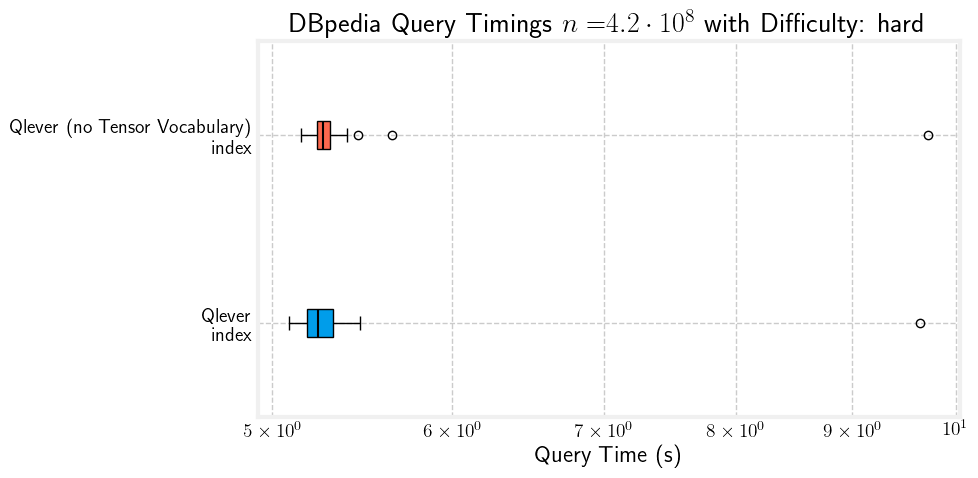

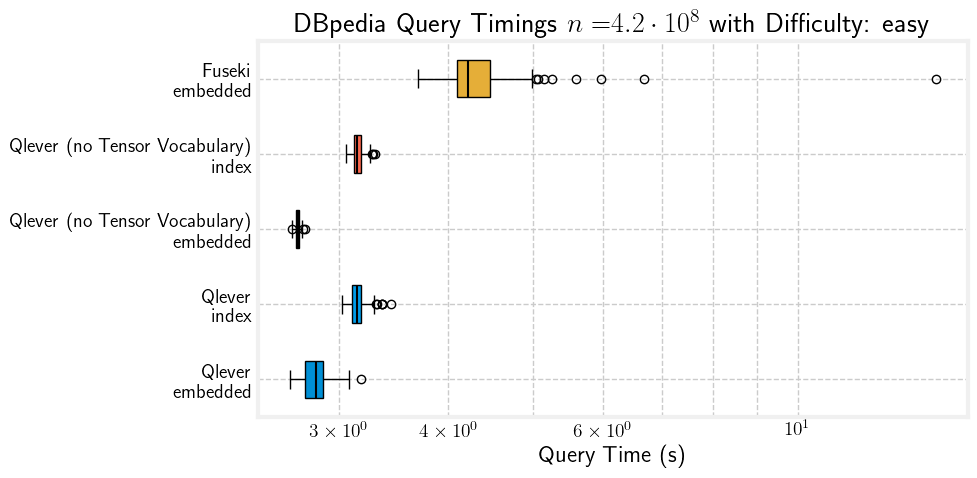

In [16]:
def plot_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    size: int,
    difficulty: str,
    relevant_measure: str = "elapsed_time",
):
    ax.set_title(f" {modes[mode]} Query Timings $n=${to_pow_10(size)} with Difficulty: {difficulty}")
    size_df = df[df["size"] == size]
    engine_types = size_df.apply(
        lambda row: (row["engine"], row["query_type"]), axis=1
    ).unique()

    tick_labels = list(engine_types)
    measures: list[pd.Series] = [
        size_df[
            (size_df["difficulty"] == difficulty)
            & (size_df["engine"] == engine)
            & (size_df["query_type"] == query_type)
        ][relevant_measure]
        for engine, query_type in tick_labels
    ]
    # filter infinite and nan values from measures and corresponding tick labels
    measures_f = [
        measures[i].replace([np.inf, -np.inf], np.nan).dropna() for i in range(len(measures))
    ]
    measures = [
        measures_f[i] for i in range(len(measures_f)) if not measures_f[i].shape[0] == 0
    ]
    tick_labels = [
        tick_labels[i] for i in range(len(tick_labels)) if not measures_f[i].shape[0] == 0
    ]
    if len(measures) == 0:
        print(f"No measures for size {size} and difficulty {difficulty}")
        return
    bplot = ax.boxplot(
        measures,
        tick_labels=[f"{engine}\n{query_type}" for engine, query_type in tick_labels],
        vert=False,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        # showfliers=False,
    )
    ax.set_xlabel("Query Time (s)")
    ax.set_xscale("log")
    ax.grid(True, which="both", ls="--")
    # fill with colors
    for patch, (engine, query_type) in zip(bplot["boxes"], tick_labels):
        patch.set_facecolor(
            adjust_lightness(colors[engine])
            if query_type == QUERY_TYPE.INDEX.value
            else colors[engine]
        )


boxplots_dir = figures_dir / "boxplots"
boxplots_dir.mkdir(exist_ok=True, parents=True)
for est_size in timings_df["estimated_size"].unique():
    for difficulty in difficulties:
        fig, ax = plt.subplots(1, figsize=(10, 5))
        eval_size = timings_df[timings_df["estimated_size"] == est_size][
            "size"
        ].unique()[0]
        plot_boxplot(ax, timings_df, eval_size, difficulty)
        plt.tight_layout()
        tikzplotlib.save(
            boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
                + ",".join(map(str, extra_y_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="0.5\\textwidth",
            axis_width="1.25\\textwidth",
        )
        plt.savefig(boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.png")
        plt.show()

In [17]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-17 15:28:20.263291,0.0,832262144,-1,-1,1,421770566,8,hard,embedded,-1,Qlever
1,2026-04-17 15:28:20.390943,149.0,1125986304,-1,-1,1,421770566,8,hard,embedded,-1,Qlever
2,2026-04-17 15:28:20.515409,96.4,1444749312,-1,-1,1,421770566,8,hard,embedded,-1,Qlever
3,2026-04-17 15:28:20.639830,96.4,1759322112,-1,-1,1,421770566,8,hard,embedded,-1,Qlever
4,2026-04-17 15:28:20.764133,104.6,2071797760,-1,-1,1,421770566,8,hard,embedded,-1,Qlever
...,...,...,...,...,...,...,...,...,...,...,...,...
26658,2026-04-17 16:29:13.499942,102.7,7838097408,-1,-1,1,421770566,8,easy,embedded,-1,Fuseki
26659,2026-04-17 16:29:13.704451,97.8,7838097408,-1,-1,1,421770566,8,easy,embedded,-1,Fuseki
26660,2026-04-17 16:29:13.915887,4020.2,7838097408,-1,-1,1,421770566,8,easy,embedded,-1,Fuseki
26661,2026-04-17 16:29:14.123255,443.5,7838097408,-1,-1,1,421770566,8,easy,embedded,-1,Fuseki


In [18]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

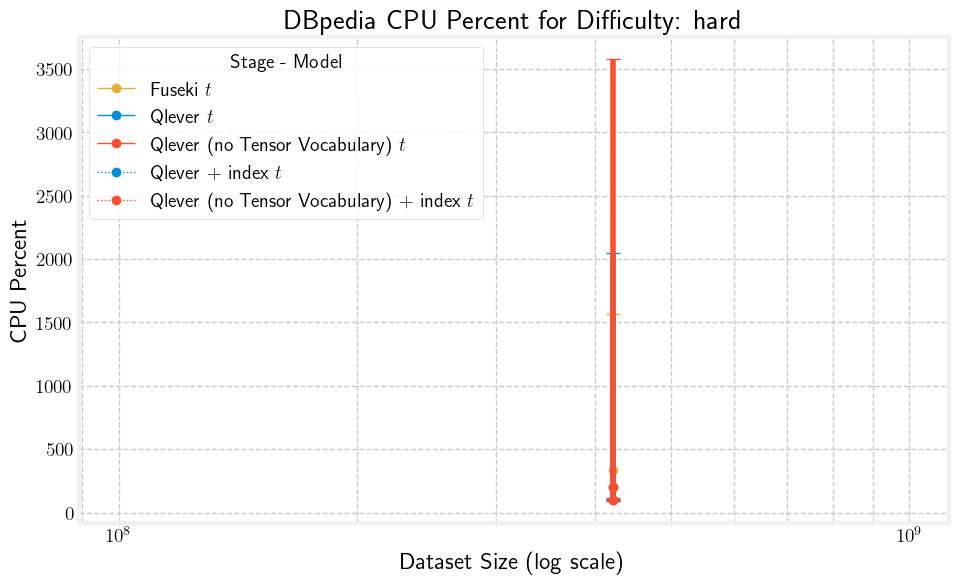

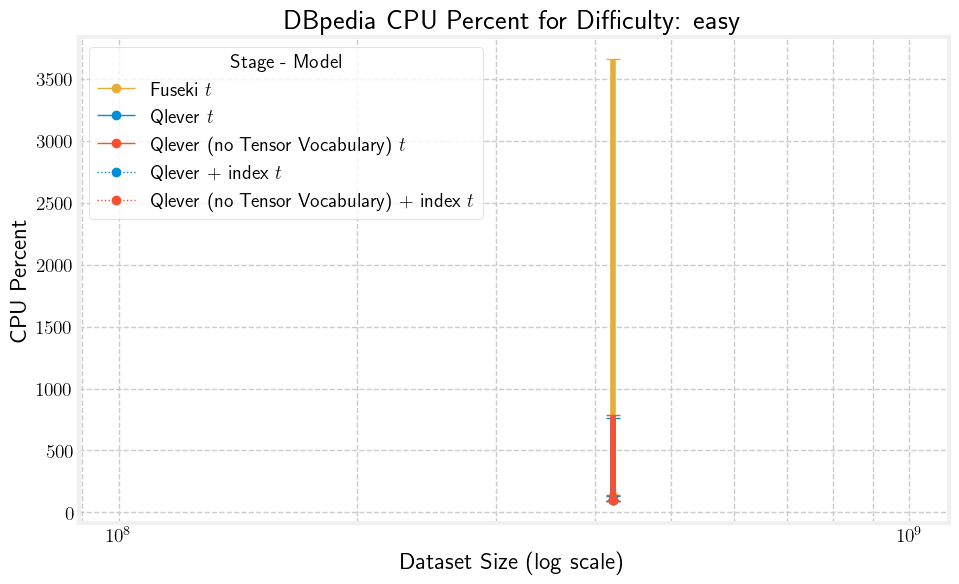

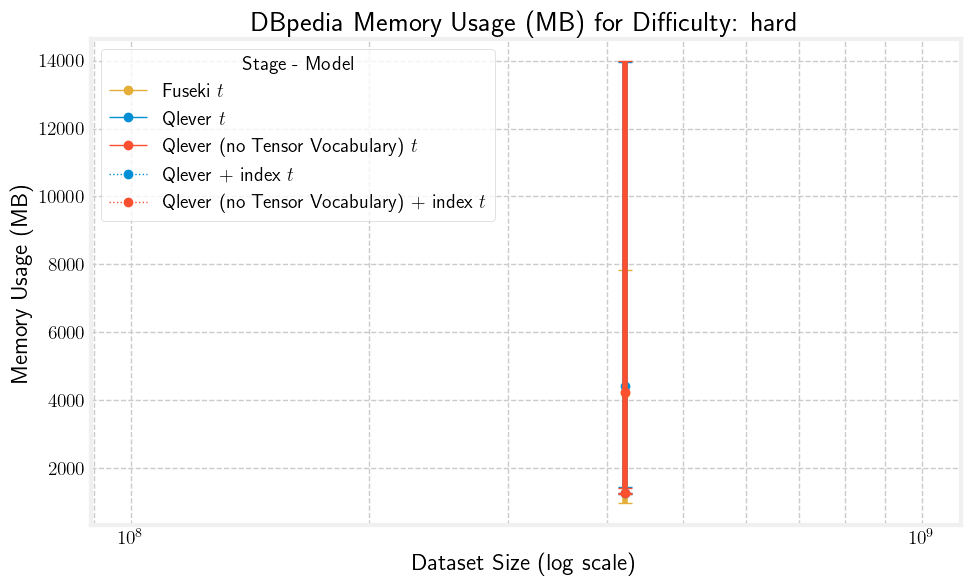

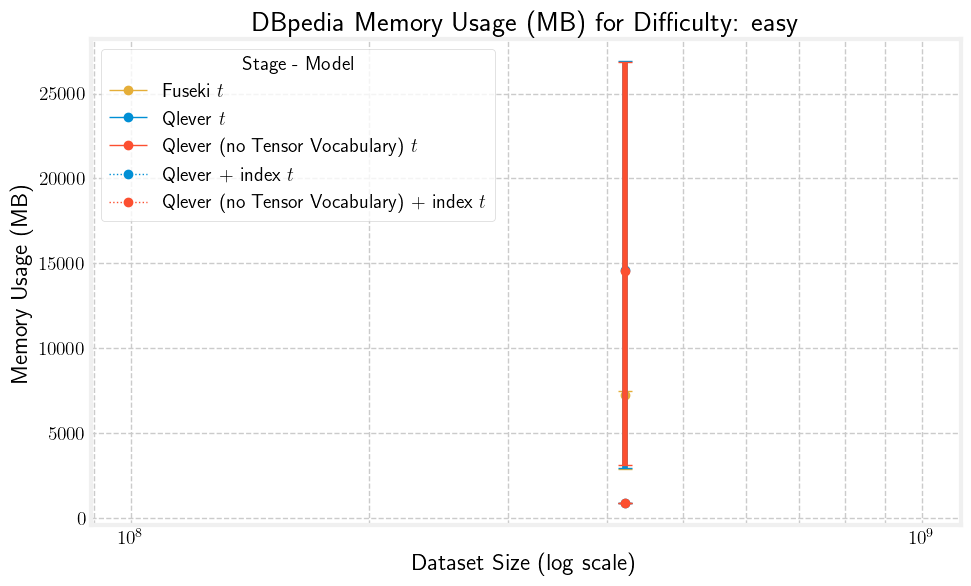

In [19]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_stats_map = {
    "cpu_percent": "CPU Percent",
    "mem_usage_mb": "Memory Usage (MB)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_stats_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            stats_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()
